# 01 — Analyse Exploratoire des Donnees (EDA) — Detection de Fraude PayLink Africa

**Objectif :** Comprendre la structure des donnees, le desequilibre des classes, et les patterns de fraude avant toute modelisation.

## 0. Imports & Configuration

In [1]:
import os, sys
WORK_DIR = r'C:\Projets\DS FINANCE QUANT\Projet 2 - Détection de Fraude en Temps Réel'
os.chdir(WORK_DIR)
print(f"Working directory: {os.getcwd()}")

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import matplotlib.ticker as mticker
from sklearn.metrics import precision_score, recall_score, f1_score

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 10})
RANDOM_STATE = 42; np.random.seed(42)

Working directory: C:\Projets\DS FINANCE QUANT\Projet 2 - Détection de Fraude en Temps Réel


## 1. Chargement des Donnees

In [2]:
# Charger les fichiers
df = pd.read_csv('data/raw/transactions.csv', parse_dates=['timestamp'])
accounts = pd.read_csv('data/raw/accounts.csv')
nodes = pd.read_csv('data/graph/nodes.csv')
edges = pd.read_csv('data/graph/edges.csv')

print(f"Transactions: {len(df):,}")
print(f"Taux fraude: {df['is_fraud'].mean()*100:.3f}%")
print(f"Periode: {df['timestamp'].min()} -> {df['timestamp'].max()}")
print(f"Comptes uniques: {accounts['account_id'].nunique():,}")
print(f"Noeuds graphe: {len(nodes):,}")
print(f"Liens (edges): {len(edges):,}")

Transactions: 2,000,000
Taux fraude: 0.150%
Periode: 2023-01-01 00:00:01 -> 2024-12-31 02:55:39
Comptes uniques: 100,000
Noeuds graphe: 100,000
Liens (edges): 1,999,555


In [3]:
# Apercu des donnees
df.head(3)

,transaction_id,timestamp,sender_id,receiver_id,amount,transaction_type,channel,device_id,city,is_fraud,...,hour,day_of_week,day_of_month,is_weekend,is_night,amount_log,sender_account_age,sender_kyc,sender_tx_count_cumulative,receiver_is_new
0,TX000000505892,2023-01-01 17:36:05,PL00000000,PL00035096,3552,deposit,web,fffe0f708916,DAK,0,...,17,6,1,1,0,8.175548,1736,3,0,1
1,TX000000636326,2023-01-05 13:57:05,PL00000000,PL00083810,2225,transfer,ussd,fde2cdc60701,ABJ,0,...,13,3,5,0,0,7.707962,1740,3,1,1
2,TX000000353697,2023-01-19 19:34:04,PL00000000,PL00089796,1280,transfer,ussd,9e544a3db548,DAK,0,...,19,3,19,0,0,7.155396,1754,3,2,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 21 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   transaction_id              str           
 1   timestamp                   datetime64[us]
 2   sender_id                   str           
 3   receiver_id                 str           
 4   amount                      int64         
 5   transaction_type            str           
 6   channel                     str           
 7   device_id                   str           
 8   city                        str           
 9   is_fraud                    int64         
 10  fraud_type                  str           
 11  hour                        int64         
 12  day_of_week                 int64         
 13  day_of_month                int64         
 14  is_weekend                  int64         
 15  is_night                    int64         
 16  amount_log                  f

In [5]:
# Valeurs manquantes
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("Aucune valeur manquante dans le dataset.")
else:
    print("Colonnes avec valeurs manquantes:")
    print(missing)

Aucune valeur manquante dans le dataset.


In [6]:
# Stats descriptives
df.describe()

,timestamp,amount,is_fraud,hour,day_of_week,day_of_month,is_weekend,is_night,amount_log,sender_account_age,sender_kyc,sender_tx_count_cumulative,receiver_is_new
count,2000000,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,2024-01-01 05:16:35.678885,2.569118e+04,1.500000e-03,1.150140e+01,2.998524e+00,1.571678e+01,2.858080e-01,3.335015e-01,9.005588e+00,1.463562e+03,1.906143e+00,2.004321e+01,9.997775e-01
min,2023-01-01 00:00:01,1.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,4.615121e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2023-07-02 17:38:29.250000,2.947000e+03,0.000000e+00,5.000000e+00,1.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,7.988882e+00,1.083000e+03,1.000000e+00,5.000000e+00,1.000000e+00
50%,2024-01-01 12:01:03.500000,8.118000e+03,0.000000e+00,1.200000e+01,3.000000e+00,1.600000e+01,0.000000e+00,0.000000e+00,9.001962e+00,1.625000e+03,2.000000e+00,1.400000e+01,1.000000e+00
75%,2024-07-01 13:10:25.500000,2.240400e+04,0.000000e+00,1.800000e+01,5.000000e+00,2.300000e+01,1.000000e+00,1.000000e+00,1.001704e+01,1.957000e+03,2.000000e+00,2.800000e+01,1.000000e+00
max,2024-12-31 02:55:39,5.000000e+06,1.000000e+00,2.300000e+01,6.000000e+00,3.100000e+01,1.000000e+00,1.000000e+00,1.542495e+01,2.555000e+03,3.000000e+00,2.230000e+02,1.000000e+00
std,NaN,7.542343e+04,3.870078e-02,6.923734e+00,2.002954e+00,8.791994e+00,4.517985e-01,4.714641e-01,1.503635e+00,6.583196e+02,7.019250e-01,2.059020e+01,1.491478e-02


## 1.1 Analyse du Desequilibre des Classes

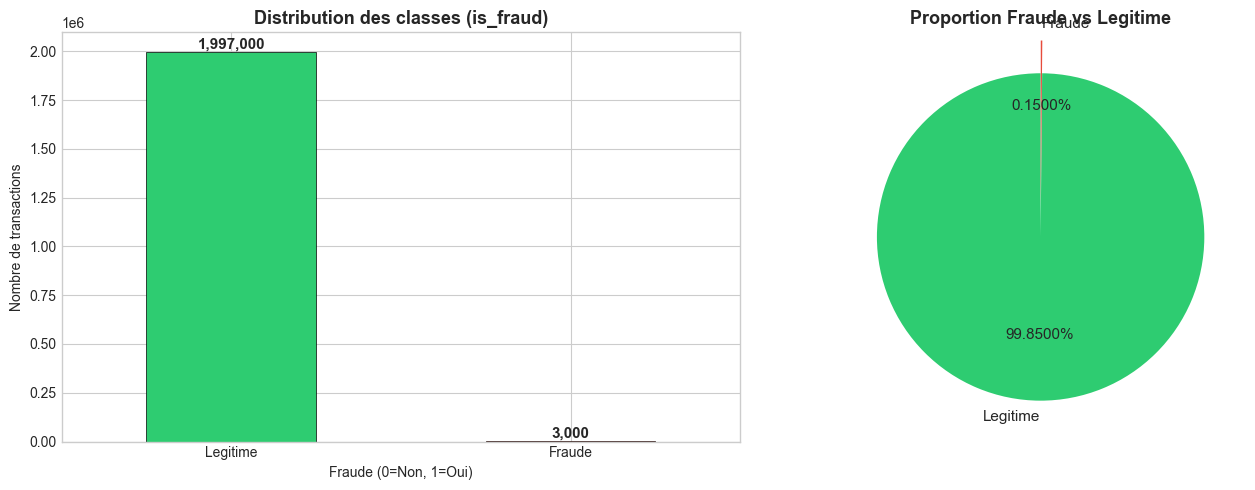

In [7]:
# Distribution is_fraud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']
ax = df['is_fraud'].value_counts().plot(
    kind='bar', color=colors, ax=axes[0], edgecolor='black', linewidth=0.5
)
axes[0].set_title('Distribution des classes (is_fraud)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fraude (0=Non, 1=Oui)')
axes[0].set_ylabel('Nombre de transactions')
axes[0].set_xticklabels(['Legitime', 'Fraude'], rotation=0)
for p in ax.patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
df['is_fraud'].value_counts().plot(
    kind='pie', labels=['Legitime', 'Fraude'], autopct='%1.4f%%',
    colors=colors, explode=(0, 0.2), ax=axes[1], startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Proportion Fraude vs Legitime', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [8]:
# Accuracy naive = 99.85% mais completement inutile
fraud_rate = df['is_fraud'].mean()
print(f"Taux de fraude global: {fraud_rate*100:.3f}%")
print(f"Accuracy naive (predire tout=0): {100 - fraud_rate*100:.3f}%")
print()
print("=> Un modele qui predit toujours 'legitime' aurait 99.85% d'accuracy")
print("   mais detecterait ZERO fraude. Metrique inadaptee !")

Taux de fraude global: 0.150%
Accuracy naive (predire tout=0): 99.850%

=> Un modele qui predit toujours 'legitime' aurait 99.85% d'accuracy
   mais detecterait ZERO fraude. Metrique inadaptee !


In [9]:
# Metriques si on predit tout = 0 (aucune fraude detectee)
y_true = df['is_fraud']
y_pred_all_zero = np.zeros(len(y_true))

precision_all0 = precision_score(y_true, y_pred_all_zero, zero_division=0)
recall_all0 = recall_score(y_true, y_pred_all_zero, zero_division=0)
f1_all0 = f1_score(y_true, y_pred_all_zero, zero_division=0)

print(f"Predire tout legitime (classe 0) :")
print(f"  Precision (fraude): {precision_all0:.4f}")
print(f"  Recall (fraude)   : {recall_all0:.4f}")
print(f"  F1-score (fraude) : {f1_all0:.4f}")
print()
print("=> F1-score = 0 : le modele naif echoue completement sur la classe minoritaire.")
print("   Necessite d'utiliser des techniques de reequilibrage (SMOTE, class_weight, etc.)")

Predire tout legitime (classe 0) :
  Precision (fraude): 0.0000
  Recall (fraude)   : 0.0000
  F1-score (fraude) : 0.0000

=> F1-score = 0 : le modele naif echoue completement sur la classe minoritaire.
   Necessite d'utiliser des techniques de reequilibrage (SMOTE, class_weight, etc.)


## 1.2 Analyse Temporelle

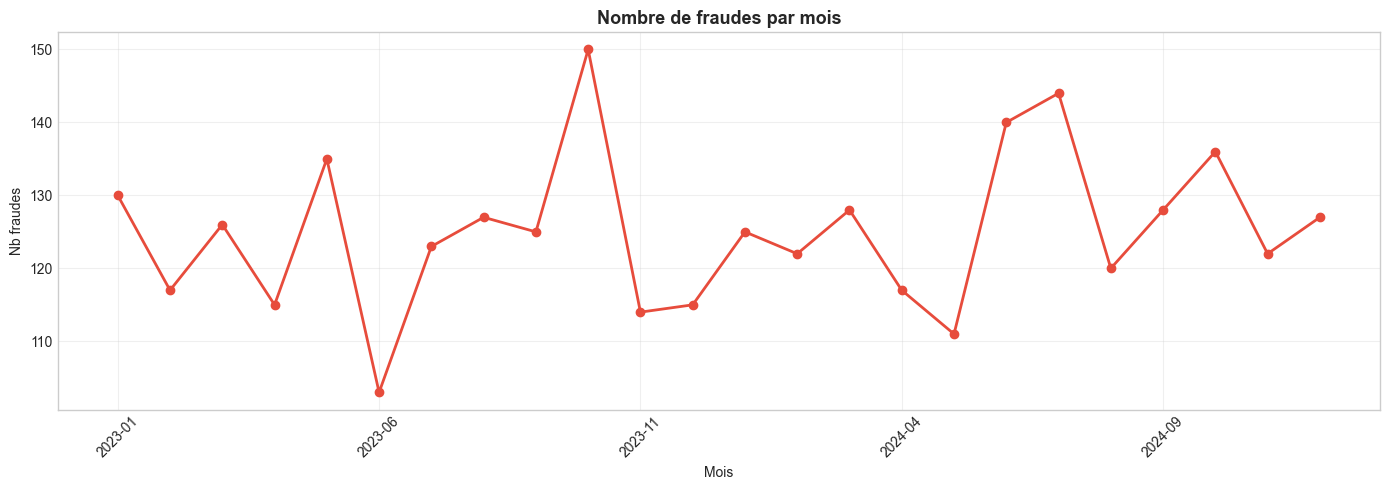

In [10]:
# Extraire mois et annee
df['year_month'] = df['timestamp'].dt.to_period('M').astype(str)
fraud_by_month = df[df['is_fraud'] == 1].groupby('year_month').size()

fig, ax = plt.subplots(figsize=(14, 5))
fraud_by_month.plot(kind='line', marker='o', color='#e74c3c', linewidth=2, markersize=6, ax=ax)
ax.set_title('Nombre de fraudes par mois', fontsize=13, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Nb fraudes')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

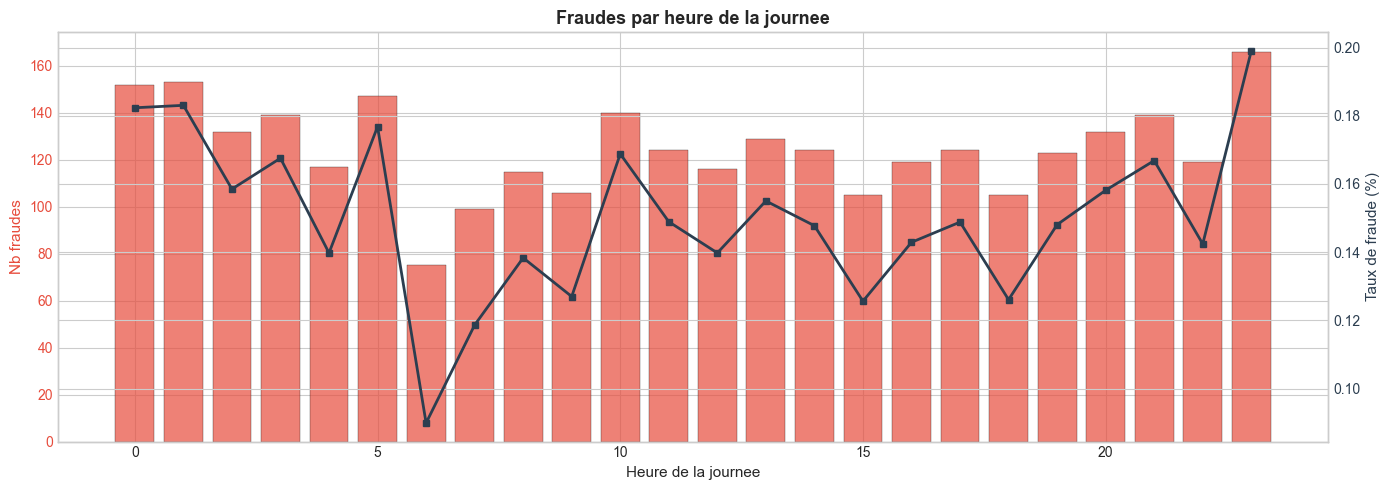

In [11]:
# Fraudes par heure de la journee
fraud_by_hour = df[df['is_fraud'] == 1].groupby('hour').size()
total_by_hour = df.groupby('hour').size()

fig, ax1 = plt.subplots(figsize=(14, 5))
color1 = '#e74c3c'
ax1.bar(fraud_by_hour.index, fraud_by_hour.values, color=color1, alpha=0.7, edgecolor='black', linewidth=0.3)
ax1.set_xlabel('Heure de la journee', fontsize=11)
ax1.set_ylabel('Nb fraudes', color=color1, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_title('Fraudes par heure de la journee', fontsize=13, fontweight='bold')

ax2 = ax1.twinx()
fraud_rate_by_hour = (fraud_by_hour / total_by_hour * 100).reindex(range(24), fill_value=0)
ax2.plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values, color='#2c3e50', linewidth=2, marker='s', markersize=4)
ax2.set_ylabel('Taux de fraude (%)', color='#2c3e50', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#2c3e50')
plt.tight_layout()
plt.show()

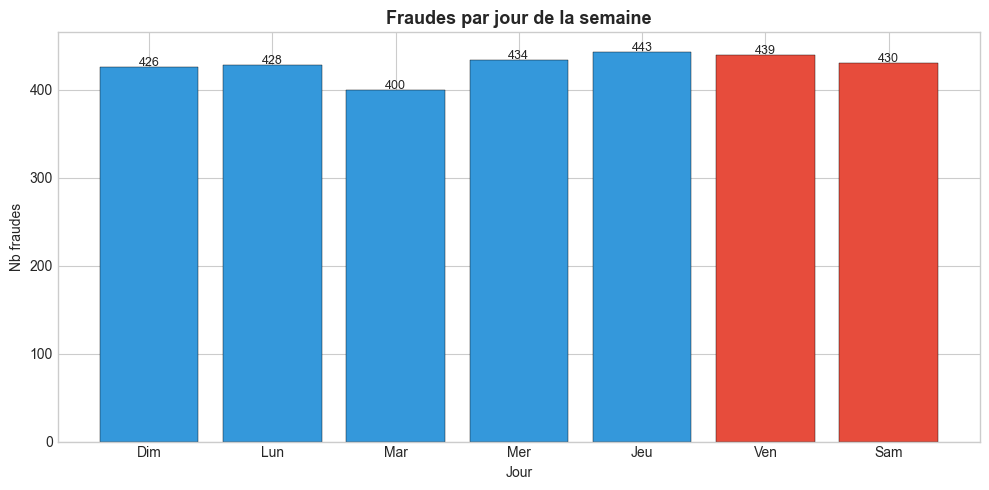

In [12]:
# Fraudes par jour de la semaine
day_names = ['Dim', 'Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam']
fraud_by_dow = df[df['is_fraud'] == 1].groupby('day_of_week').size()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(7), fraud_by_dow.reindex(range(7), fill_value=0).values,
              color=['#e74c3c' if i in [5, 6] else '#3498db' for i in range(7)],
              edgecolor='black', linewidth=0.3)
ax.set_xticks(range(7))
ax.set_xticklabels(day_names)
ax.set_title('Fraudes par jour de la semaine', fontsize=13, fontweight='bold')
ax.set_xlabel('Jour')
ax.set_ylabel('Nb fraudes')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+1,
            int(bar.get_height()), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

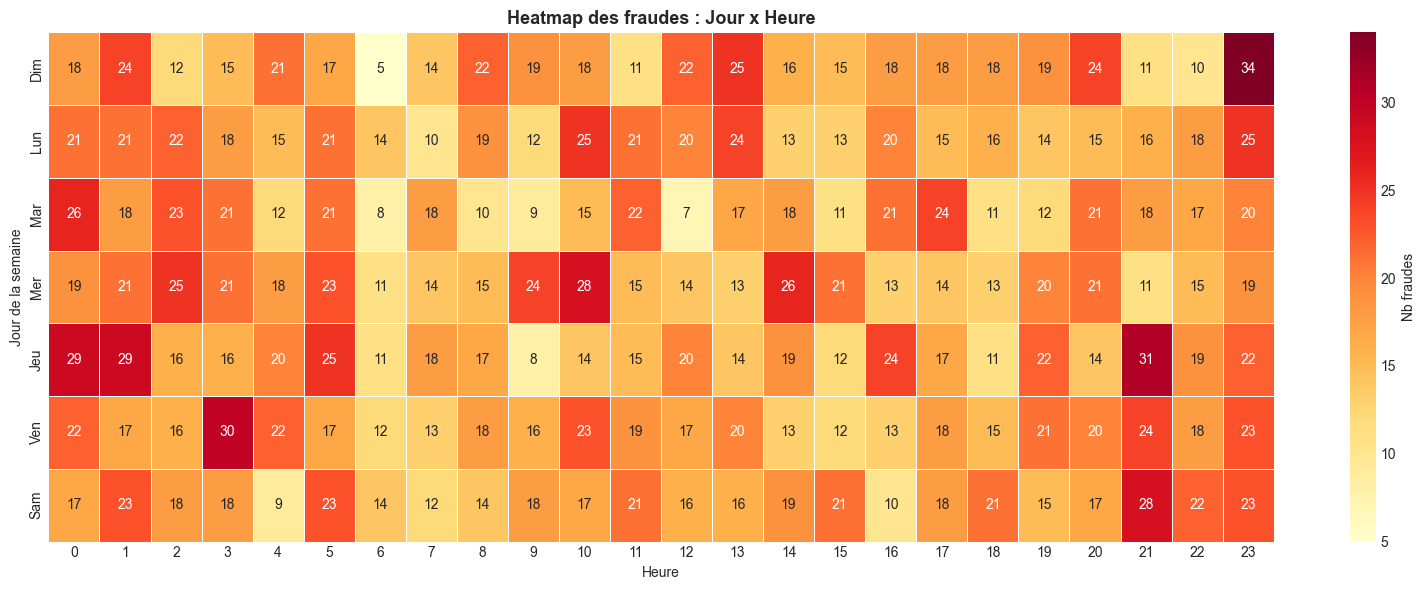

In [13]:
# Heatmap jour x heure des fraudes
fraud_heatmap = df[df['is_fraud'] == 1].pivot_table(
    index='day_of_week', columns='hour', aggfunc='size', fill_value=0
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(fraud_heatmap.reindex(index=range(7), fill_value=0),
            cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5,
            xticklabels=range(24), yticklabels=day_names, ax=ax,
            cbar_kws={'label': 'Nb fraudes'})
ax.set_title('Heatmap des fraudes : Jour x Heure', fontsize=13, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Jour de la semaine')
plt.tight_layout()
plt.show()

## 1.3 Analyse par Type de Fraude

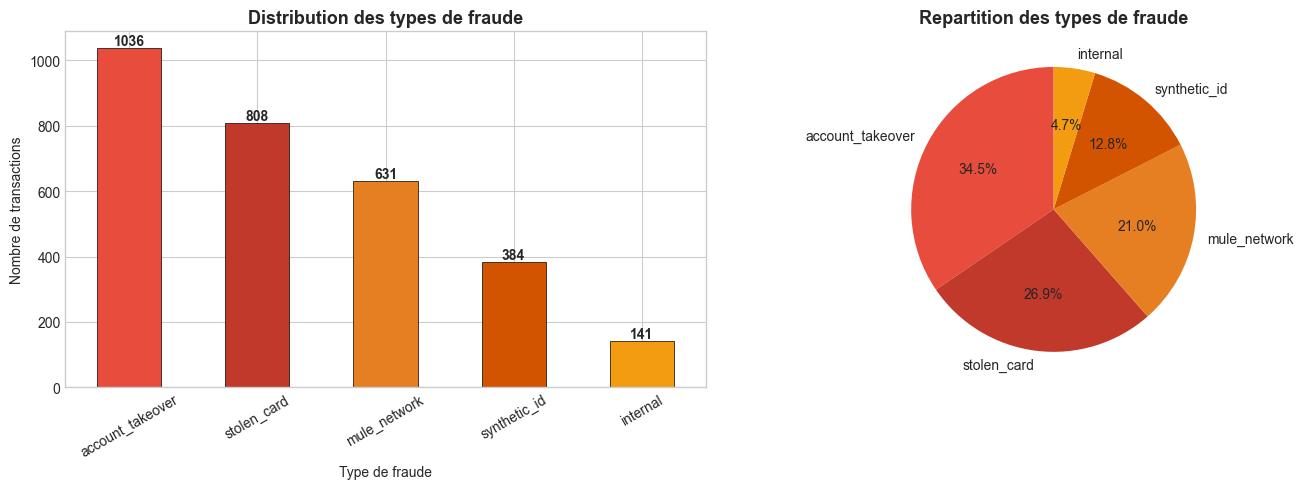

In [14]:
# Distribution des fraud_type (hors 'none')
fraud_only = df[df['is_fraud'] == 1]
fraud_type_dist = fraud_only['fraud_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#c0392b', '#e67e22', '#d35400', '#f39c12']
fraud_type_dist.plot(kind='bar', color=colors, edgecolor='black', linewidth=0.5, ax=axes[0])
axes[0].set_title('Distribution des types de fraude', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Type de fraude')
axes[0].set_ylabel('Nombre de transactions')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

fraud_type_dist.plot(kind='pie', autopct='%1.1f%%', colors=colors, ax=axes[1], startangle=90)
axes[1].set_title('Repartition des types de fraude', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [15]:
# Montant moyen par type de fraude
avg_amount_by_fraud = fraud_only.groupby('fraud_type')['amount'].agg(['mean', 'median', 'count']).round(0)
avg_amount_by_fraud.columns = ['Montant moyen', 'Montant median', 'Nb transactions']
print("Montants par type de fraude:")
avg_amount_by_fraud

Montants par type de fraude:


,Montant moyen,Montant median,Nb transactions
fraud_type,,,
account_takeover,1051708.0,1062473.0,1036
internal,293333.0,290000.0,141
mule_network,269878.0,272831.0,631
stolen_card,28248.0,29132.0,808
synthetic_id,582848.0,574236.0,384


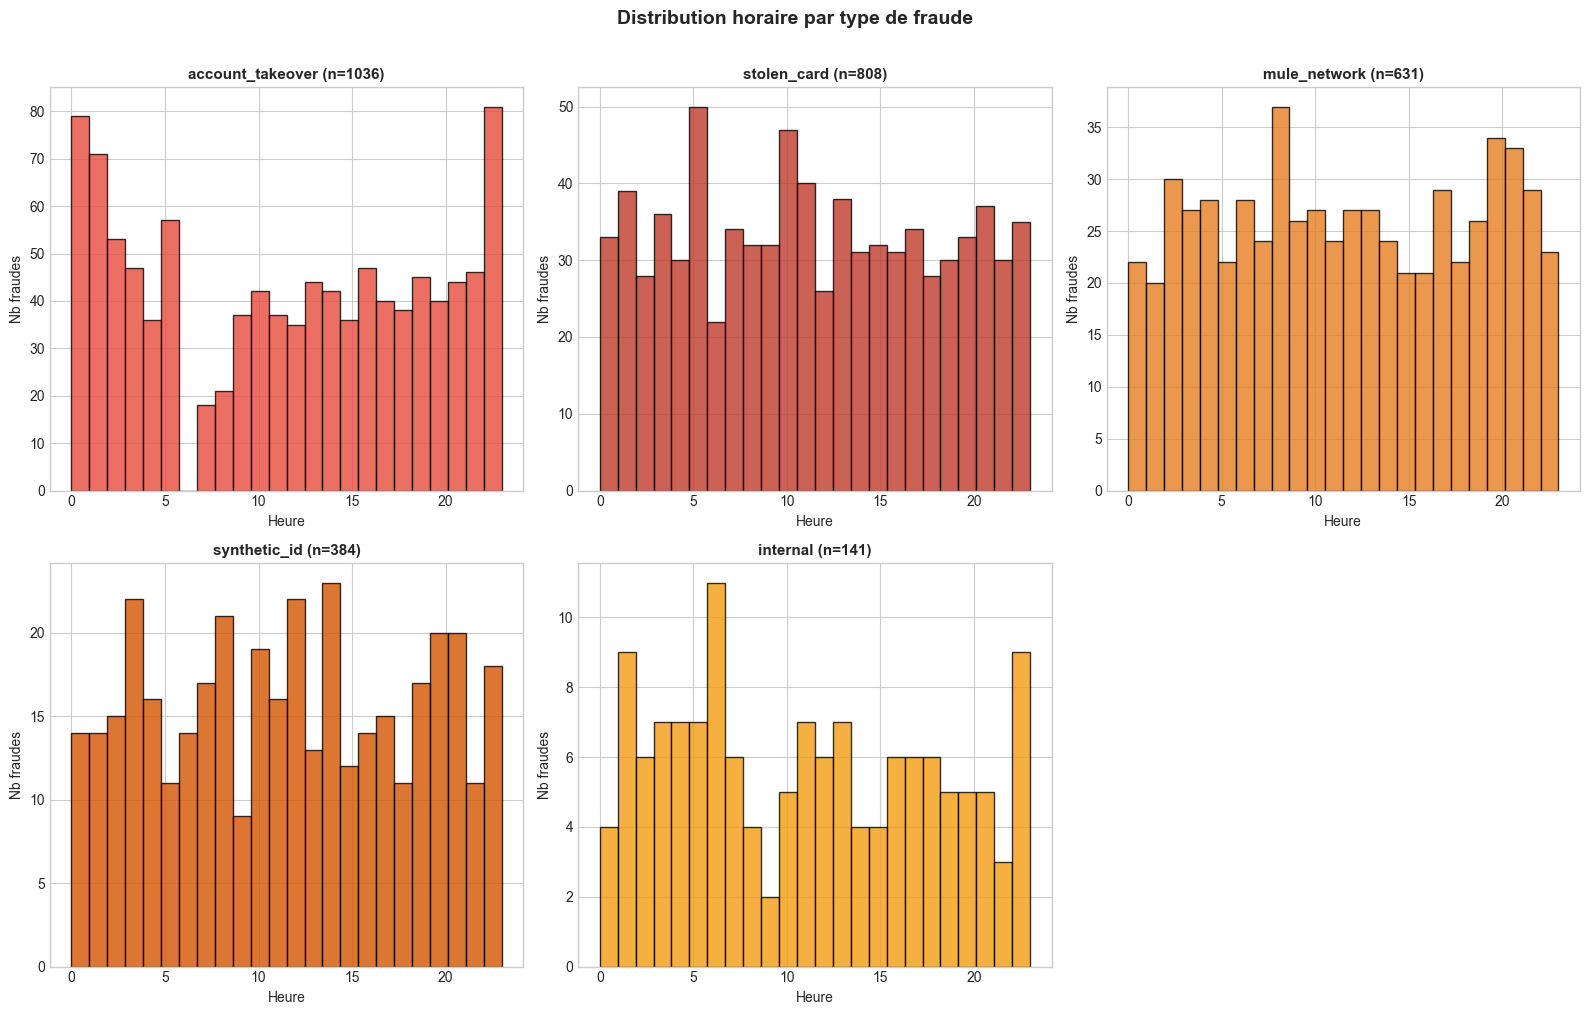

In [16]:
# Heure typique par type de fraude
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, ftype in enumerate(fraud_type_dist.index):
    data = fraud_only[fraud_only['fraud_type'] == ftype]
    data['hour'].hist(bins=24, color=colors[i], edgecolor='black', ax=axes[i], alpha=0.8)
    axes[i].set_title(f'{ftype} (n={len(data)})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Heure')
    axes[i].set_ylabel('Nb fraudes')

# Hide unused subplot
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution horaire par type de fraude', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 1.4 Analyse des Canaux et Devices

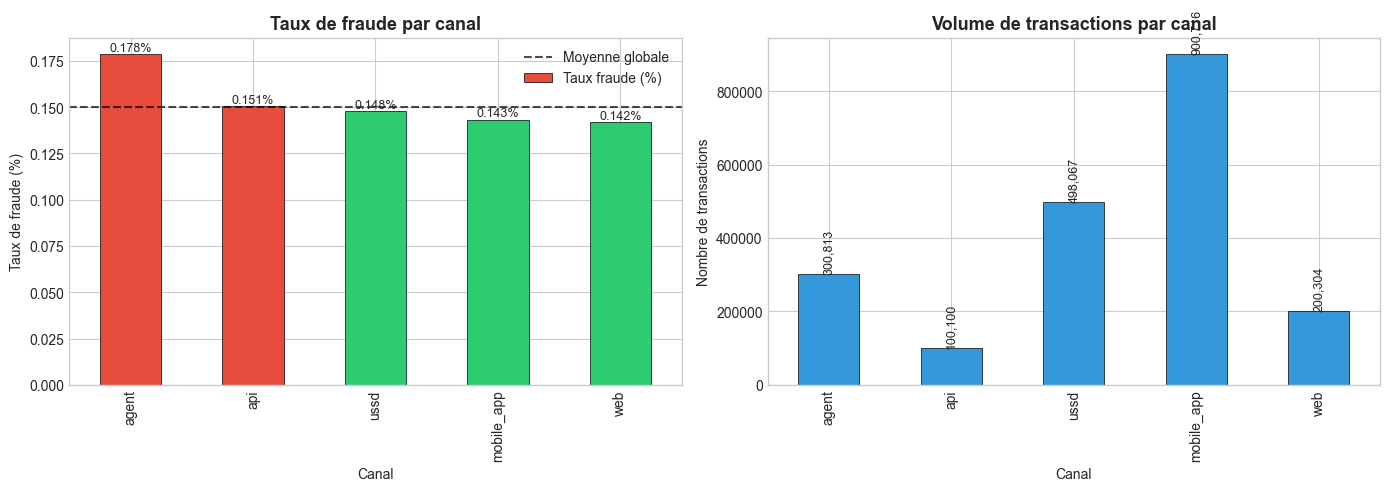

,Nb fraudes,Nb total,Taux fraude (%)
channel,,,
agent,537,300813,0.1785
api,151,100100,0.1508
ussd,737,498067,0.1480
mobile_app,1291,900716,0.1433
web,284,200304,0.1418


In [17]:
# Taux de fraude par canal
fraud_by_channel = df.groupby('channel')['is_fraud'].agg(['sum', 'count'])
fraud_by_channel['taux_fraude_%'] = (fraud_by_channel['sum'] / fraud_by_channel['count'] * 100).round(4)
fraud_by_channel.columns = ['Nb fraudes', 'Nb total', 'Taux fraude (%)']
fraud_by_channel = fraud_by_channel.sort_values('Taux fraude (%)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart taux
ax = fraud_by_channel['Taux fraude (%)'].plot(
    kind='bar', color=['#e74c3c' if v > df['is_fraud'].mean()*100 else '#2ecc71'
                       for v in fraud_by_channel['Taux fraude (%)']],
    edgecolor='black', linewidth=0.5, ax=axes[0]
)
axes[0].set_title('Taux de fraude par canal', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Canal')
axes[0].set_ylabel('Taux de fraude (%)')
axes[0].axhline(y=df['is_fraud'].mean()*100, color='black', linestyle='--', alpha=0.7, label='Moyenne globale')
axes[0].legend()
for p in ax.patches:
    axes[0].annotate(f'{p.get_height():.3f}%', (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Volume
fraud_by_channel['Nb total'].plot(
    kind='bar', color='#3498db', edgecolor='black', linewidth=0.5, ax=axes[1]
)
axes[1].set_title('Volume de transactions par canal', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Canal')
axes[1].set_ylabel('Nombre de transactions')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, rotation=90)
plt.tight_layout()
plt.show()

fraud_by_channel

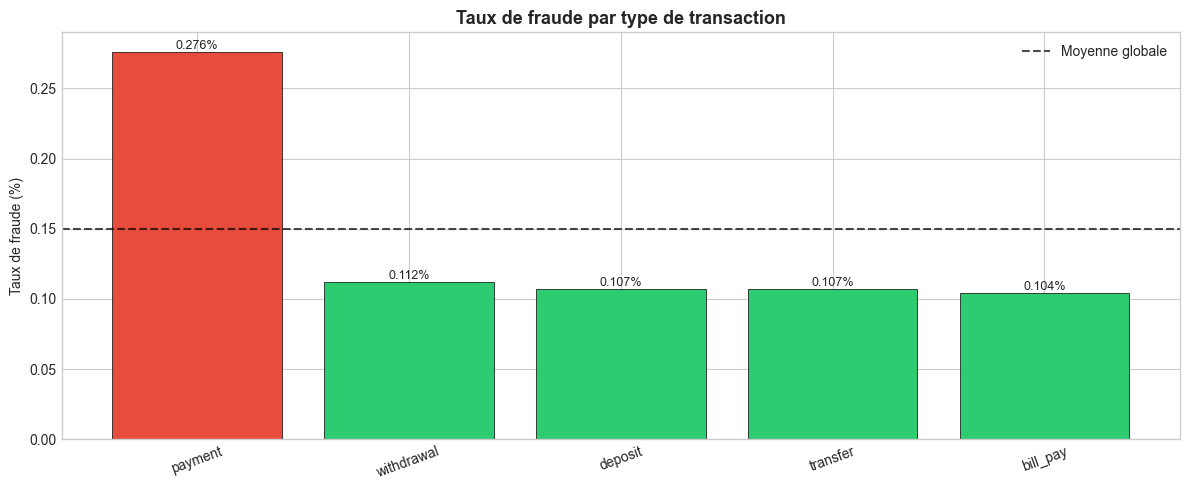

In [18]:
# Taux de fraude par type de transaction
fraud_by_txtype = df.groupby('transaction_type')['is_fraud'].agg(['sum', 'count'])
fraud_by_txtype['taux_fraude_%'] = (fraud_by_txtype['sum'] / fraud_by_txtype['count'] * 100).round(4)
fraud_by_txtype = fraud_by_txtype.sort_values('taux_fraude_%', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors_tx = ['#e74c3c' if v > df['is_fraud'].mean()*100 else '#2ecc71'
             for v in fraud_by_txtype['taux_fraude_%']]
bars = ax.bar(range(len(fraud_by_txtype)), fraud_by_txtype['taux_fraude_%'],
              color=colors_tx, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(fraud_by_txtype)))
ax.set_xticklabels(fraud_by_txtype.index, rotation=20)
ax.set_title('Taux de fraude par type de transaction', fontsize=13, fontweight='bold')
ax.set_ylabel('Taux de fraude (%)')
ax.axhline(y=df['is_fraud'].mean()*100, color='black', linestyle='--', alpha=0.7, label='Moyenne globale')
ax.legend()
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.002,
            f'{bar.get_height():.3f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

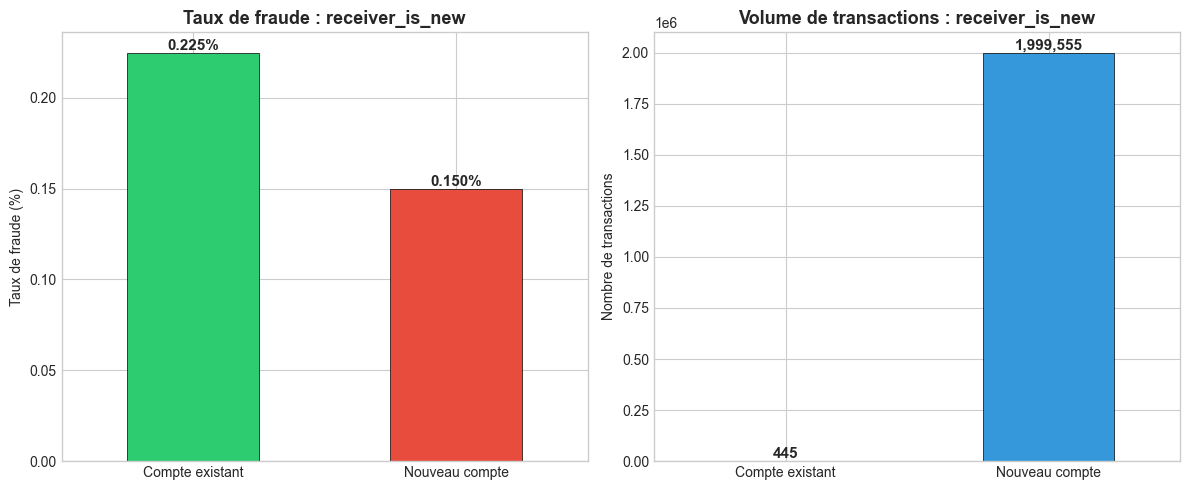

,sum,count,mean,taux_fraude_%
Compte existant,1,445,0.002247,0.2247
Nouveau compte,2999,1999555,0.001500,0.1500


In [19]:
# receiver_is_new : destinataire nouveau vs ancien
fraud_by_new = df.groupby('receiver_is_new')['is_fraud'].agg(['sum', 'count', 'mean'])
fraud_by_new['taux_fraude_%'] = (fraud_by_new['mean'] * 100).round(4)
fraud_by_new.index = ['Compte existant', 'Nouveau compte']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Taux
ax = fraud_by_new['taux_fraude_%'].plot(
    kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5, ax=axes[0]
)
axes[0].set_title('Taux de fraude : receiver_is_new', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Taux de fraude (%)')
axes[0].tick_params(axis='x', rotation=0)
for p in ax.patches:
    axes[0].annotate(f'{p.get_height():.3f}%', (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# Volume
fraud_by_new['count'].plot(
    kind='bar', color=['#2ecc71', '#3498db'], edgecolor='black', linewidth=0.5, ax=axes[1]
)
axes[1].set_title('Volume de transactions : receiver_is_new', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nombre de transactions')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

fraud_by_new

## 1.5 Analyse des Comptes

In [20]:
# Joindre transactions avec comptes pour analyse
# On merge sur sender_id = account_id
df_w_accounts = df.merge(
    accounts[['account_id', 'country', 'kyc_level', 'account_age_days']],
    left_on='sender_id', right_on='account_id', how='left'
)
print(f"Transactions avec infos compte: {len(df_w_accounts):,}")
df_w_accounts[['sender_id', 'country', 'kyc_level', 'account_age_days']].head(3)

Transactions avec infos compte: 2,000,000


,sender_id,country,kyc_level,account_age_days
0,PL00000000,SEN,3,2466
1,PL00000000,SEN,3,2466
2,PL00000000,SEN,3,2466


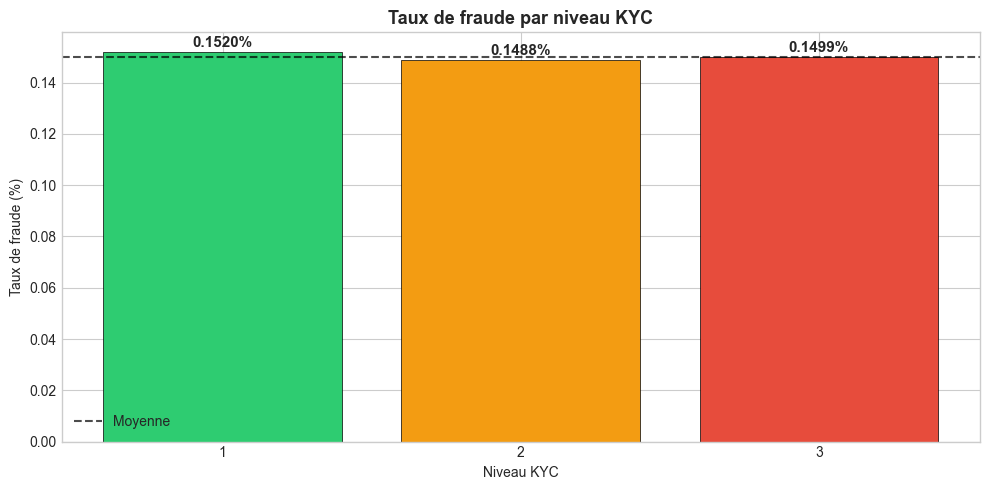

,sum,count,mean,taux_fraude_%
kyc_level,,,,
1,905,595364,0.001520,0.1520
2,1484,996985,0.001488,0.1488
3,611,407651,0.001499,0.1499


In [21]:
# Taux de fraude par niveau KYC
fraud_by_kyc = df_w_accounts.groupby('kyc_level')['is_fraud'].agg(['sum', 'count', 'mean'])
fraud_by_kyc['taux_fraude_%'] = (fraud_by_kyc['mean'] * 100).round(4)
fraud_by_kyc = fraud_by_kyc.sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
colors_kyc = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(fraud_by_kyc.index.astype(str), fraud_by_kyc['taux_fraude_%'],
              color=colors_kyc, edgecolor='black', linewidth=0.5)
ax.set_title('Taux de fraude par niveau KYC', fontsize=13, fontweight='bold')
ax.set_xlabel('Niveau KYC')
ax.set_ylabel('Taux de fraude (%)')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.002,
            f'{bar.get_height():.4f}%', ha='center', fontsize=11, fontweight='bold')
ax.axhline(y=df['is_fraud'].mean()*100, color='black', linestyle='--', alpha=0.7, label='Moyenne')
ax.legend()
plt.tight_layout()
plt.show()

fraud_by_kyc

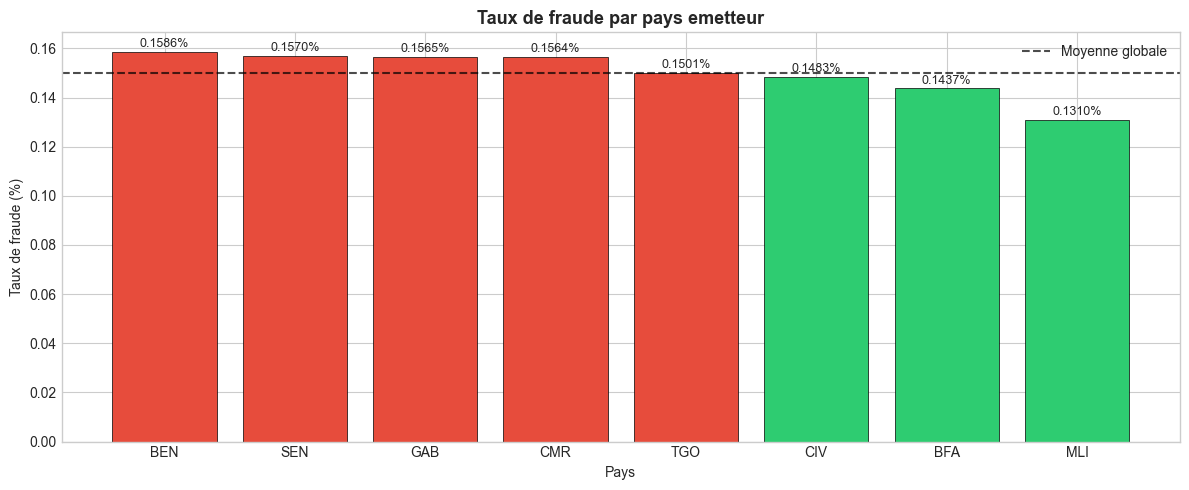

,sum,count,mean,taux_fraude_%
country,,,,
BEN,255,160742,0.001586,0.1586
SEN,788,502051,0.001570,0.1570
GAB,154,98433,0.001565,0.1565
CMR,249,159224,0.001564,0.1564
TGO,303,201930,0.001501,0.1501
CIV,651,438954,0.001483,0.1483
BFA,288,200421,0.001437,0.1437
MLI,312,238245,0.001310,0.1310


In [22]:
# Taux de fraude par pays
fraud_by_country = df_w_accounts.groupby('country')['is_fraud'].agg(['sum', 'count', 'mean'])
fraud_by_country['taux_fraude_%'] = (fraud_by_country['mean'] * 100).round(4)
fraud_by_country = fraud_by_country.sort_values('taux_fraude_%', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(fraud_by_country.index, fraud_by_country['taux_fraude_%'],
              color=['#e74c3c' if v > df['is_fraud'].mean()*100 else '#2ecc71'
                     for v in fraud_by_country['taux_fraude_%']],
              edgecolor='black', linewidth=0.5)
ax.set_title('Taux de fraude par pays emetteur', fontsize=13, fontweight='bold')
ax.set_xlabel('Pays')
ax.set_ylabel('Taux de fraude (%)')
ax.axhline(y=df['is_fraud'].mean()*100, color='black', linestyle='--', alpha=0.7, label='Moyenne globale')
ax.legend()
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.002,
            f'{bar.get_height():.4f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

fraud_by_country

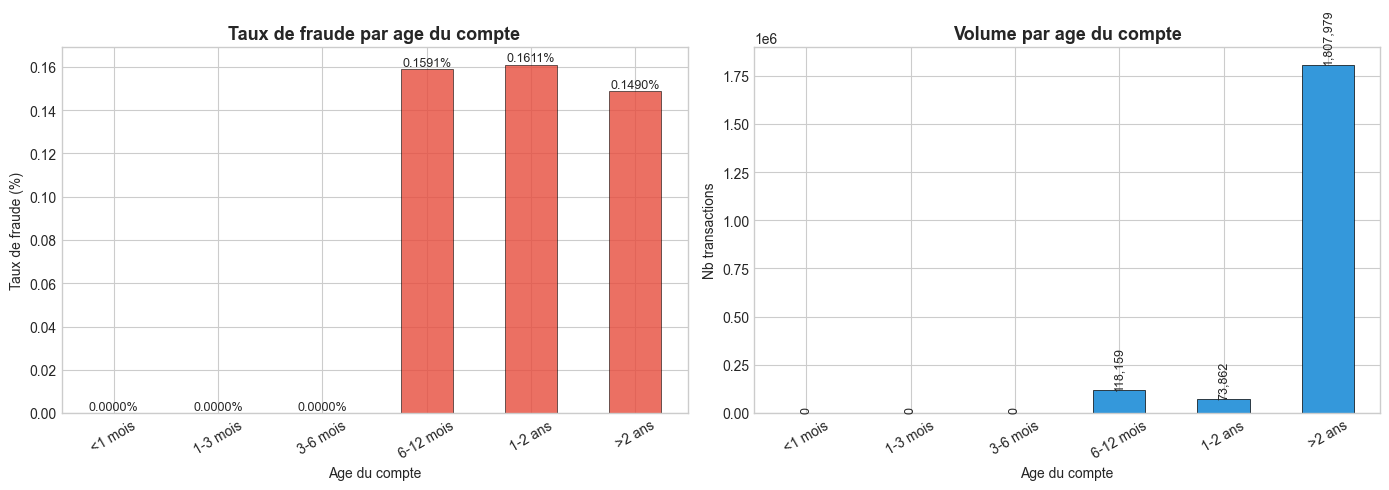

,sum,count,mean,taux_fraude_%
age_bucket,,,,
<1 mois,0,0,NaN,NaN
1-3 mois,0,0,NaN,NaN
3-6 mois,0,0,NaN,NaN
6-12 mois,188,118159,0.001591,0.1591
1-2 ans,119,73862,0.001611,0.1611
>2 ans,2693,1807979,0.001490,0.1490


In [23]:
# Age du compte vs fraude
df_w_accounts['age_bucket'] = pd.cut(
    df_w_accounts['account_age_days'],
    bins=[0, 30, 90, 180, 365, 730, 5000],
    labels=['<1 mois', '1-3 mois', '3-6 mois', '6-12 mois', '1-2 ans', '>2 ans']
)

fraud_by_age = df_w_accounts.groupby('age_bucket', observed=False)['is_fraud'].agg(['sum', 'count', 'mean'])
fraud_by_age['taux_fraude_%'] = (fraud_by_age['mean'] * 100).round(4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux
ax = fraud_by_age['taux_fraude_%'].plot(
    kind='bar', color='#e74c3c', edgecolor='black', linewidth=0.5, ax=axes[0], alpha=0.8
)
axes[0].set_title('Taux de fraude par age du compte', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age du compte')
axes[0].set_ylabel('Taux de fraude (%)')
axes[0].tick_params(axis='x', rotation=30)
for p in ax.patches:
    axes[0].annotate(f'{p.get_height():.4f}%', (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Volume
fraud_by_age['count'].plot(
    kind='bar', color='#3498db', edgecolor='black', linewidth=0.5, ax=axes[1]
)
axes[1].set_title('Volume par age du compte', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age du compte')
axes[1].set_ylabel('Nb transactions')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, rotation=90)
plt.tight_layout()
plt.show()

fraud_by_age

## 1.6 Analyse du Graphe de Transactions

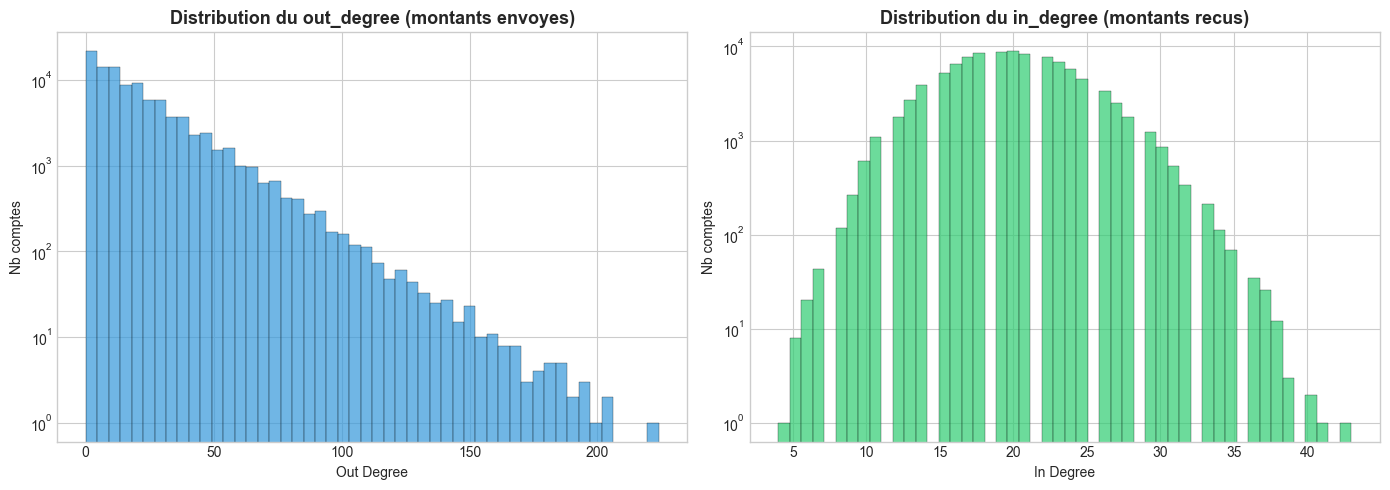

Out degree  - mean: 20.0, median: 14.0, max: 224
In degree   - mean: 20.0, median: 20.0, max: 43


In [24]:
# Distribution du degre (out_degree, in_degree)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(nodes['out_degree'], bins=50, color='#3498db', edgecolor='black', alpha=0.7, linewidth=0.3)
axes[0].set_title('Distribution du out_degree (montants envoyes)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Out Degree')
axes[0].set_ylabel('Nb comptes')
axes[0].set_yscale('log')

axes[1].hist(nodes['in_degree'], bins=50, color='#2ecc71', edgecolor='black', alpha=0.7, linewidth=0.3)
axes[1].set_title('Distribution du in_degree (montants recus)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('In Degree')
axes[1].set_ylabel('Nb comptes')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Out degree  - mean: {nodes['out_degree'].mean():.1f}, median: {nodes['out_degree'].median():.1f}, max: {nodes['out_degree'].max():.0f}")
print(f"In degree   - mean: {nodes['in_degree'].mean():.1f}, median: {nodes['in_degree'].median():.1f}, max: {nodes['in_degree'].max():.0f}")

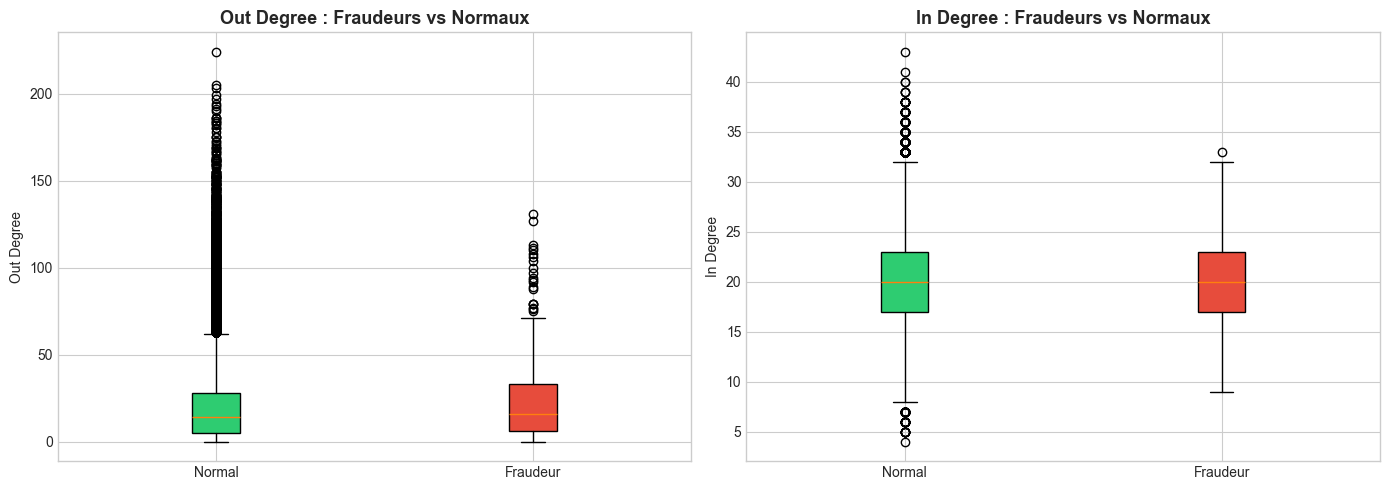

Fraudeurs - out_degree mean: 23.5, in_degree mean: 19.9
Normaux   - out_degree mean: 20.0, in_degree mean: 20.0


In [25]:
# Comptes fraudeurs vs normaux : degre
fraud_nodes = nodes[nodes['is_fraud_account'] == 1]
normal_nodes = nodes[nodes['is_fraud_account'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot out_degree
data_out = [normal_nodes['out_degree'], fraud_nodes['out_degree']]
bp1 = axes[0].boxplot(data_out, labels=['Normal', 'Fraudeur'], patch_artist=True)
bp1['boxes'][0].set_facecolor('#2ecc71'); bp1['boxes'][1].set_facecolor('#e74c3c')
axes[0].set_title('Out Degree : Fraudeurs vs Normaux', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Out Degree')

# Boxplot in_degree
data_in = [normal_nodes['in_degree'], fraud_nodes['in_degree']]
bp2 = axes[1].boxplot(data_in, labels=['Normal', 'Fraudeur'], patch_artist=True)
bp2['boxes'][0].set_facecolor('#2ecc71'); bp2['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('In Degree : Fraudeurs vs Normaux', fontsize=13, fontweight='bold')
axes[1].set_ylabel('In Degree')

plt.tight_layout()
plt.show()

print(f"Fraudeurs - out_degree mean: {fraud_nodes['out_degree'].mean():.1f}, in_degree mean: {fraud_nodes['in_degree'].mean():.1f}")
print(f"Normaux   - out_degree mean: {normal_nodes['out_degree'].mean():.1f}, in_degree mean: {normal_nodes['in_degree'].mean():.1f}")

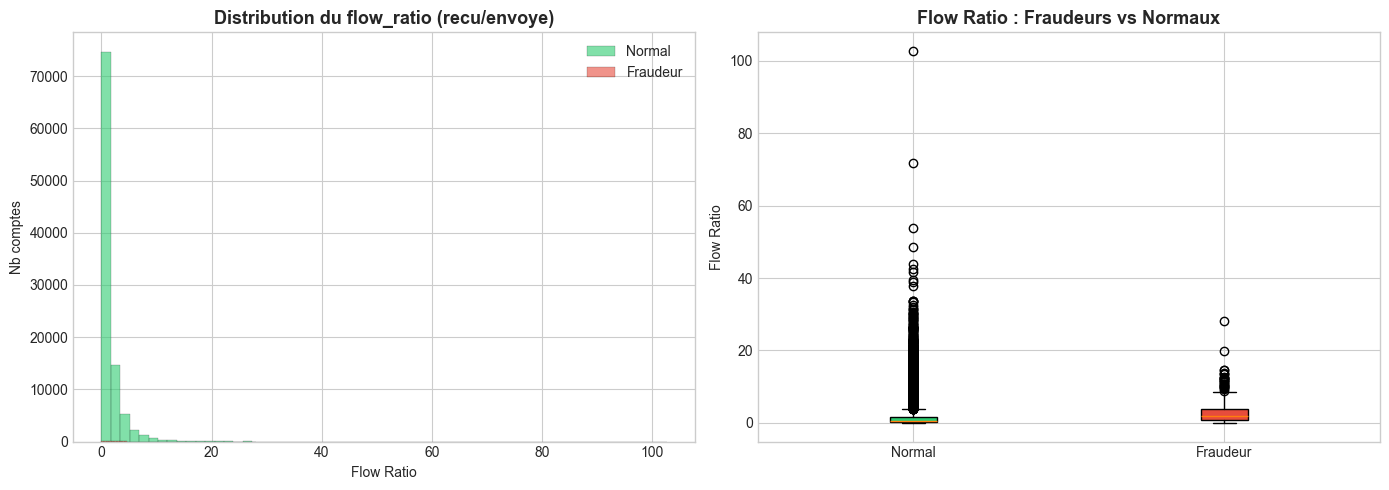

Flow ratio normal   - mean: 1.40, median: 0.67
Flow ratio fraudeur - mean: 2.91, median: 1.90

=> Un flow_ratio eleve (beaucoup recu, peu envoye) peut indiquer un compte mule.


In [26]:
# flow_ratio (recu/envoye) pour fraudeurs vs normaux
# Filtrer les valeurs finies
valid_nodes = nodes[(nodes['flow_ratio'].notna()) & (np.isfinite(nodes['flow_ratio']))]
fraud_flow = valid_nodes[valid_nodes['is_fraud_account'] == 1]['flow_ratio']
normal_flow = valid_nodes[valid_nodes['is_fraud_account'] == 0]['flow_ratio']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogrammes
axes[0].hist(normal_flow, bins=60, color='#2ecc71', alpha=0.6, label='Normal', edgecolor='black', linewidth=0.2)
axes[0].hist(fraud_flow, bins=60, color='#e74c3c', alpha=0.6, label='Fraudeur', edgecolor='black', linewidth=0.2)
axes[0].set_title('Distribution du flow_ratio (recu/envoye)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Flow Ratio')
axes[0].set_ylabel('Nb comptes')
axes[0].legend()

# Boxplot
data_flow = [normal_flow, fraud_flow]
bp = axes[1].boxplot(data_flow, labels=['Normal', 'Fraudeur'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71'); bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Flow Ratio : Fraudeurs vs Normaux', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Flow Ratio')

plt.tight_layout()
plt.show()

print(f"Flow ratio normal   - mean: {normal_flow.mean():.2f}, median: {normal_flow.median():.2f}")
print(f"Flow ratio fraudeur - mean: {fraud_flow.mean():.2f}, median: {fraud_flow.median():.2f}")
print()
print("=> Un flow_ratio eleve (beaucoup recu, peu envoye) peut indiquer un compte mule.")

In [27]:
# Liens frauduleux dans le graphe
fraud_edges = edges[edges['has_fraud'] == 1]
print(f"Liens totaux: {len(edges):,}")
print(f"Liens avec fraude: {len(fraud_edges):,} ({len(fraud_edges)/len(edges)*100:.3f}%)")
print()

# Top paires avec le plus de fraude
print("Top 5 liens avec le plus de transactions frauduleuses:")
fraud_edges.nlargest(5, 'tx_count')[['source', 'target', 'tx_count', 'has_fraud', 'total_amount']]

Liens totaux: 1,999,555
Liens avec fraude: 3,000 (0.150%)

Top 5 liens avec le plus de transactions frauduleuses:


,source,target,tx_count,has_fraud,total_amount
1306041,PL00065506,PL00001501,2,1,105624
1509592,PL00075698,PL00003796,2,1,1169382
504,PL00000018,PL00094311,1,1,1550498
1442,PL00000068,PL00019631,1,1,1823609
1450,PL00000068,PL00042877,1,1,42677


## 1.1b Visualisation des valeurs manquantes — missingno

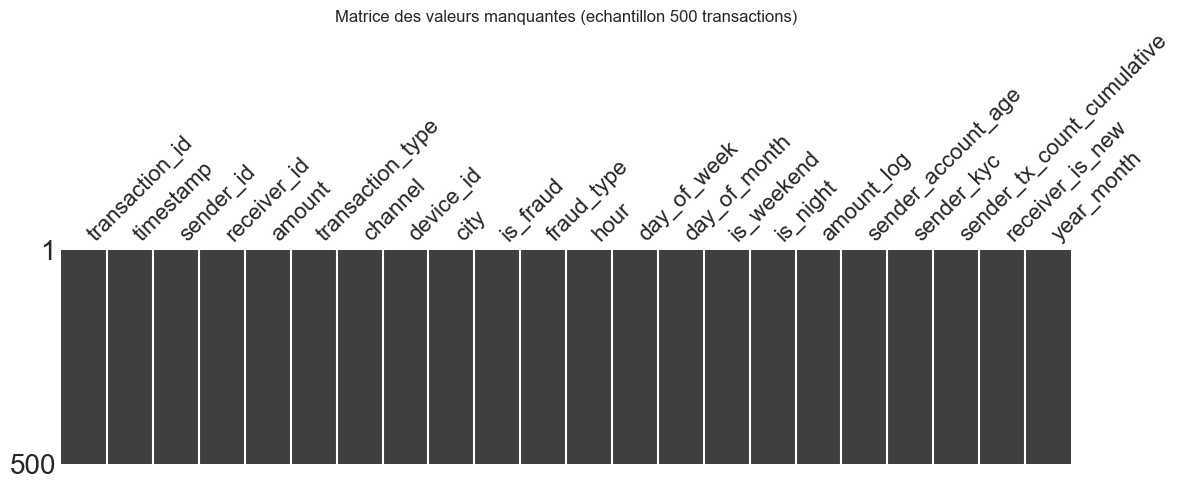

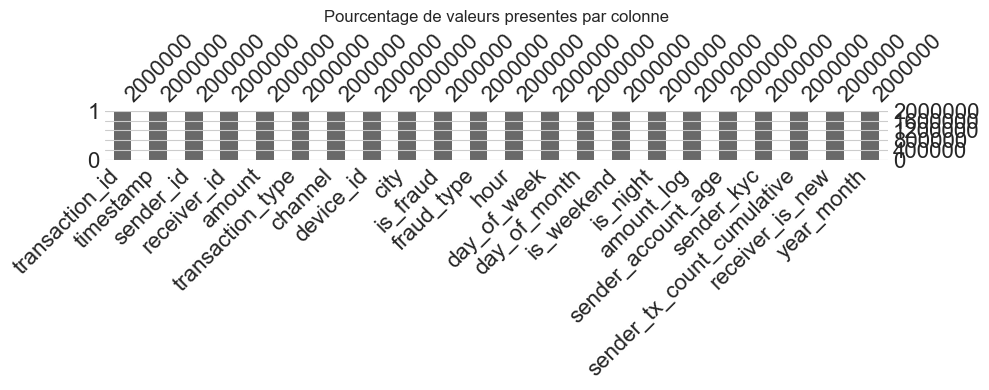

Colonnes avec valeurs manquantes :
Series([], dtype: int64)


In [28]:
# 1.1b missingno — Visualisation des valeurs manquantes
import missingno as msno

# Matrice de manquants
fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(df.sample(500), ax=ax)
ax.set_title('Matrice des valeurs manquantes (echantillon 500 transactions)')
plt.tight_layout()
plt.show()

# Barplot des manquants
fig, ax = plt.subplots(figsize=(10, 4))
msno.bar(df, ax=ax)
ax.set_title('Pourcentage de valeurs presentes par colonne')
plt.tight_layout()
plt.show()

print("Colonnes avec valeurs manquantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])

## 1.1c Analyse univariee — Distributions

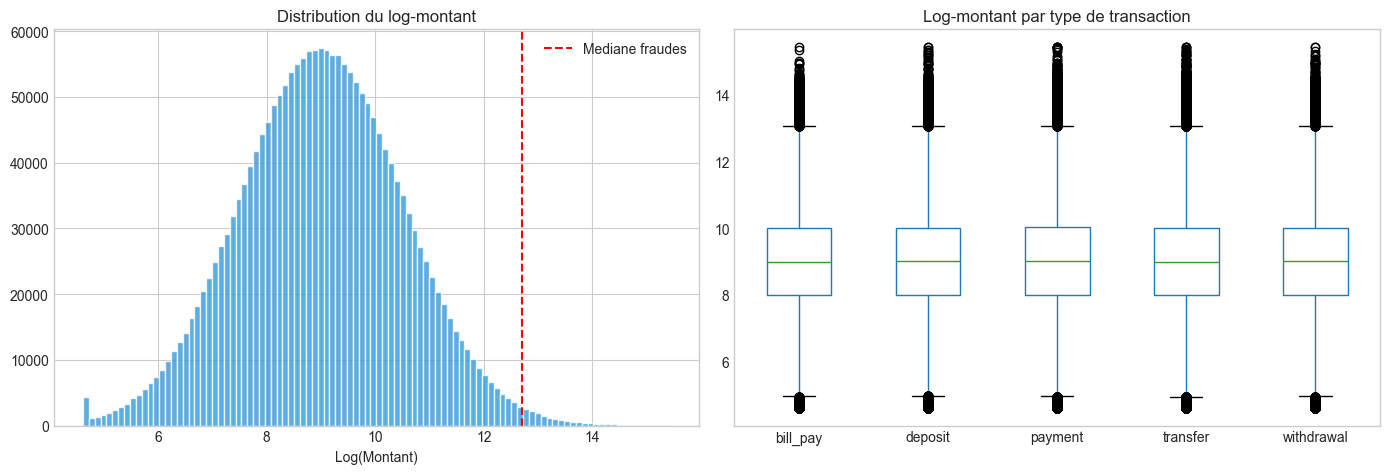

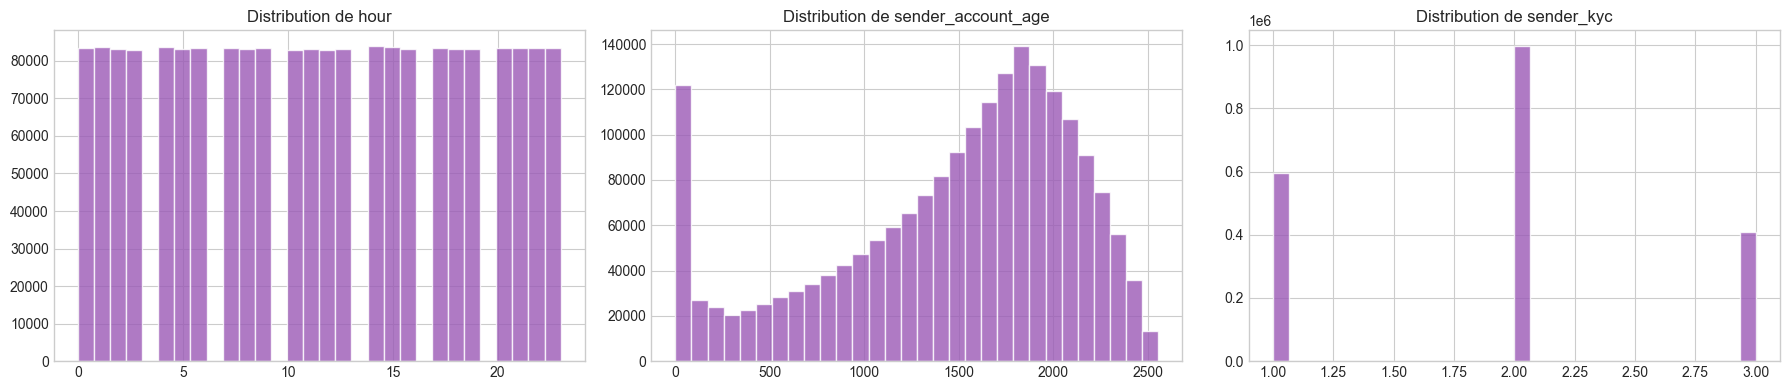

Skewness & Kurtosis (top 10 numeriques) :
                    skewness  kurtosis
is_fraud               25.76    661.67
amount                 16.64    551.70
is_weekend              0.95     -1.10
is_night                0.71     -1.50
sender_kyc              0.13     -0.97
amount_log              0.03     -0.02
day_of_month            0.01     -1.19
day_of_week             0.00     -1.25
hour                   -0.00     -1.20
sender_account_age     -0.76     -0.31


In [29]:
# 1.1c Analyse univariee — Distributions
# Distribution du montant (log-scale pour lisibilite)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['amount_log'], bins=100, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Log(Montant)')
axes[0].set_title('Distribution du log-montant')
axes[0].axvline(x=df[df['is_fraud']==1]['amount_log'].median(), color='red',
                linestyle='--', label='Mediane fraudes')
axes[0].legend()

# Boxplot montant par type de transaction
df.boxplot(column='amount_log', by='transaction_type', ax=axes[1], grid=False)
axes[1].set_title('Log-montant par type de transaction')
axes[1].set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Distribution de l'age du compte et autres features
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(['hour', 'sender_account_age', 'sender_kyc']):
    if col in df.columns:
        df[col].hist(bins=30, ax=axes[i], color='#9b59b6', edgecolor='white', alpha=0.8)
        axes[i].set_title(f'Distribution de {col}')
plt.tight_layout()
plt.show()

# Skewness et kurtosis
num_cols_univ = df.select_dtypes(include=[np.number]).columns[:10]
stats_univar = pd.DataFrame({
    'skewness': df[num_cols_univ].skew(),
    'kurtosis': df[num_cols_univ].kurtosis(),
}).round(2)
print("Skewness & Kurtosis (top 10 numeriques) :")
print(stats_univar.sort_values('skewness', ascending=False))

## 1.1d Analyse bivariee — Correlations

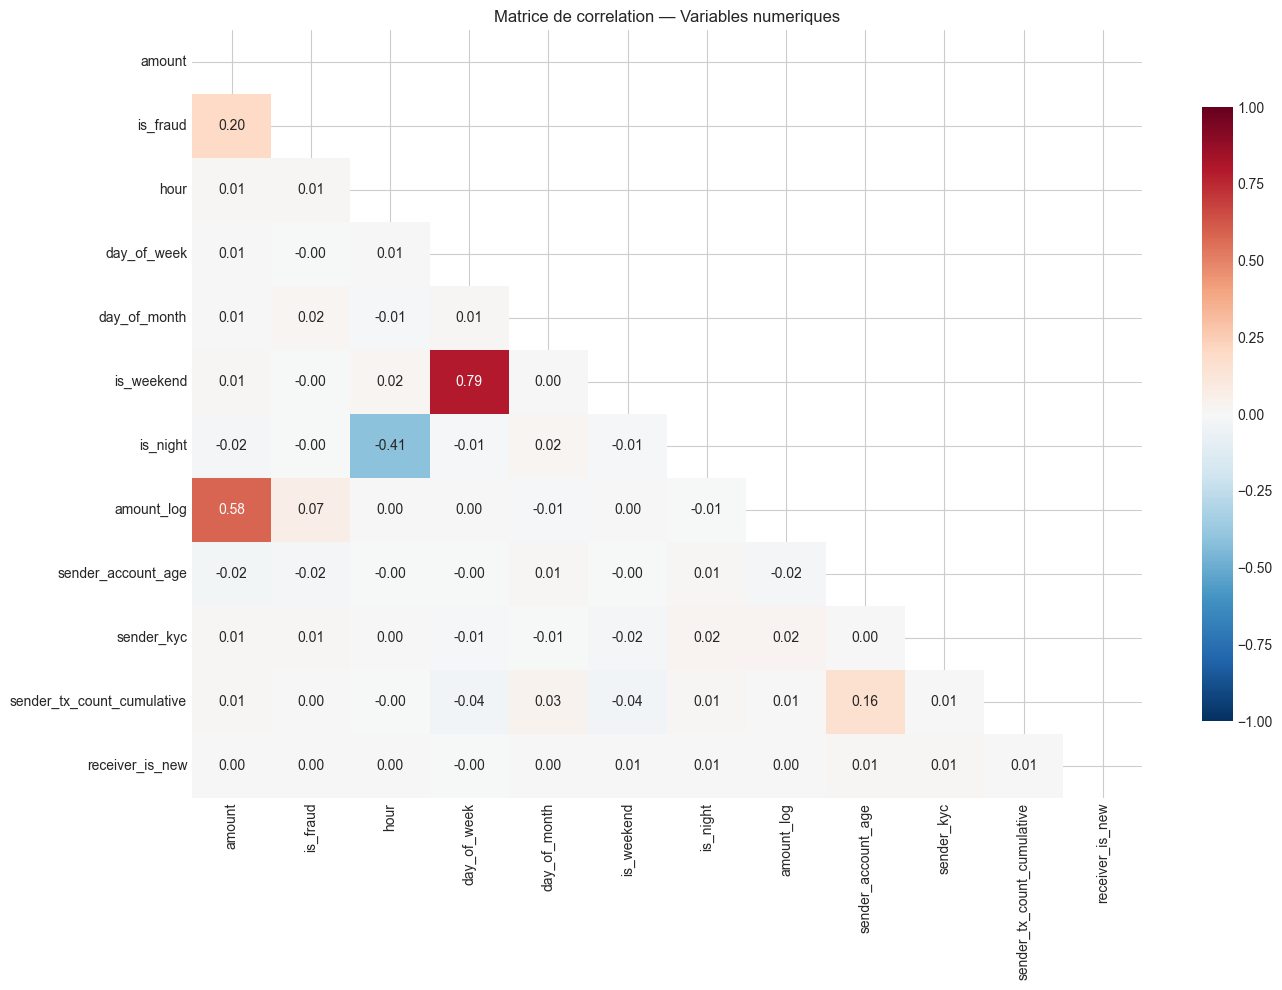

Top 10 correlations avec is_fraud :
amount                        0.197855
amount_log                    0.068035
day_of_month                  0.018893
sender_account_age           -0.017924
sender_kyc                    0.013918
hour                          0.010901
is_weekend                   -0.004031
day_of_week                  -0.003333
sender_tx_count_cumulative    0.002842
is_night                     -0.000511
Name: is_fraud, dtype: float64


In [30]:
# 1.1d Analyse bivariee — Correlations
# Matrice de correlation (variables numeriques principales)
num_cols = df.select_dtypes(include=[np.number]).columns
sample_corr = df[num_cols].sample(10000, random_state=42)

fig, ax = plt.subplots(figsize=(14, 10))
corr = sample_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de correlation — Variables numeriques')
plt.tight_layout()
plt.show()

# Top correlations avec is_fraud
corr_with_target = corr['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)
print("Top 10 correlations avec is_fraud :")
print(corr_with_target.head(10))

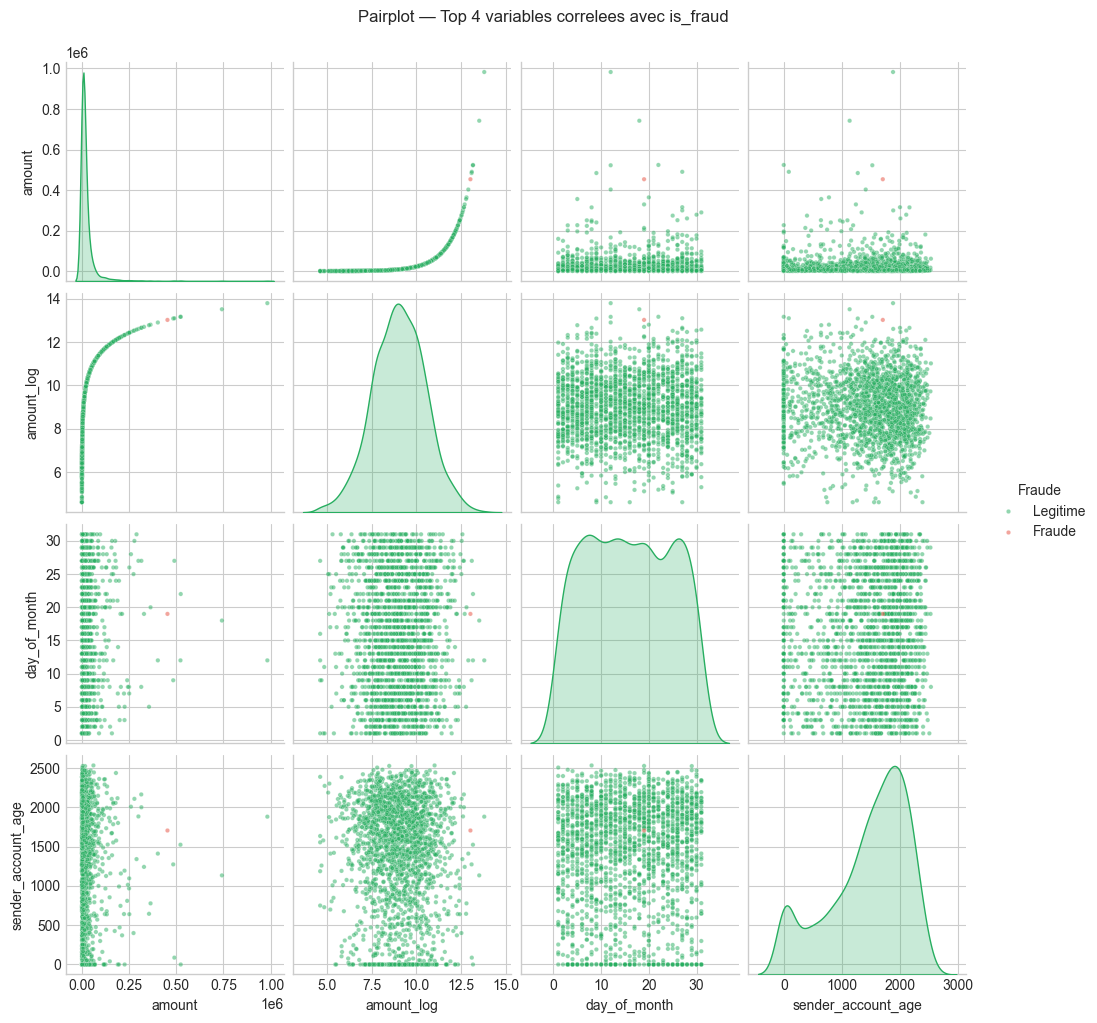

In [31]:
# Pairplot des top variables (echantillon pour lisibilite)
top_vars = corr_with_target.head(4).index.tolist() + ['is_fraud']
sample_pair = df[top_vars].sample(2000, random_state=42)
sample_pair['Fraude'] = sample_pair['is_fraud'].map({0: 'Legitime', 1: 'Fraude'})
g = sns.pairplot(sample_pair.drop(columns=['is_fraud']), hue='Fraude',
                  palette={'Legitime': '#27ae60', 'Fraude': '#e74c3c'},
                  diag_kind='kde', plot_kws={'alpha': 0.5, 's': 10})
g.fig.suptitle('Pairplot — Top 4 variables correlees avec is_fraud', y=1.02)
plt.show()

## 1.1e Analyse multivariee — PCA (ACP)

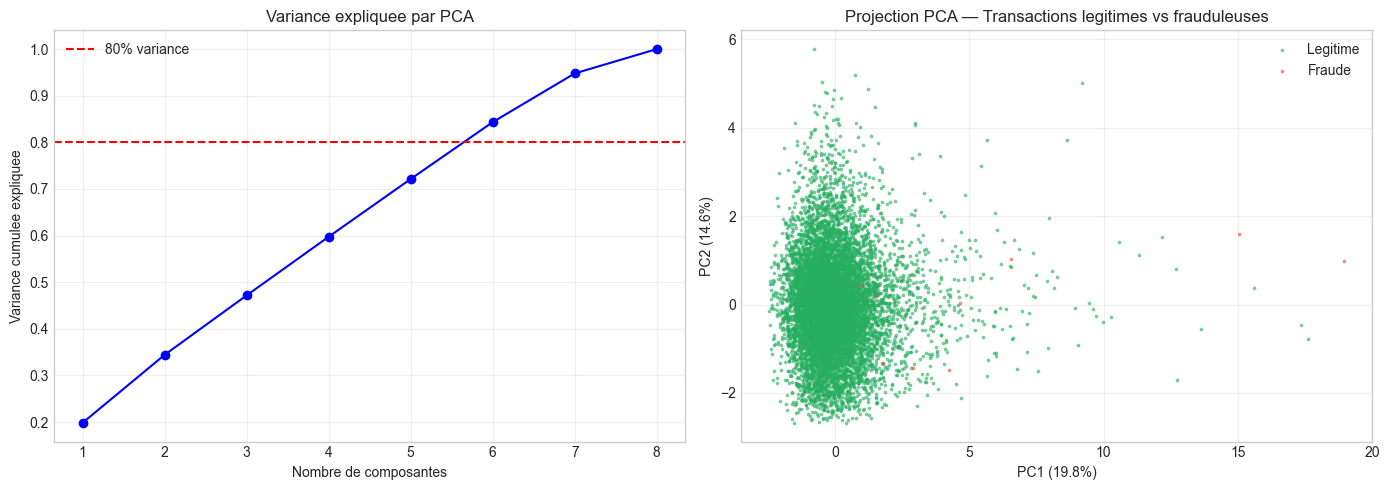

Top 10 contributeurs a PC1 :
                      feature   loading
4                  amount_log  0.705443
0                      amount  0.705159
5          sender_account_age  0.053317
6                  sender_kyc  0.043073
1                        hour  0.013715
7  sender_tx_count_cumulative  0.009819
2                 day_of_week  0.008532
3                day_of_month  0.006834


In [32]:
# 1.1e Analyse multivariee — PCA (ACP)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Preparer donnees pour PCA
num_cols_pca = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ['is_fraud', 'transaction_id'] and df[c].nunique() > 2]
sample_pca = df[num_cols_pca].sample(10000, random_state=42).dropna()
sample_labels = df.loc[sample_pca.index, 'is_fraud']

# Standardiser
scaler = StandardScaler()
X_scaled = scaler.fit_transform(sample_pca)

# PCA
pca = PCA(n_components=min(10, len(num_cols_pca)))
X_pca = pca.fit_transform(X_scaled)

# Variance expliquee
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(pca.explained_variance_ratio_)+1),
            np.cumsum(pca.explained_variance_ratio_), 'bo-')
axes[0].axhline(y=0.80, color='r', linestyle='--', label='80% variance')
axes[0].set_xlabel('Nombre de composantes')
axes[0].set_ylabel('Variance cumulee expliquee')
axes[0].set_title('Variance expliquee par PCA')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Projection 2D (PC1 vs PC2)
for label_val, color, label_name in [(0, '#27ae60', 'Legitime'), (1, '#e74c3c', 'Fraude')]:
    mask = sample_labels == label_val
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label_name, alpha=0.5, s=3)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Projection PCA — Transactions legitimes vs frauduleuses')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Top contributeurs a PC1
pc1_loadings = pd.DataFrame({
    'feature': num_cols_pca,
    'loading': np.abs(pca.components_[0])
}).sort_values('loading', ascending=False)
print("Top 10 contributeurs a PC1 :")
print(pc1_loadings.head(10))

## 1.1f DBSCAN — Clustering non supervise

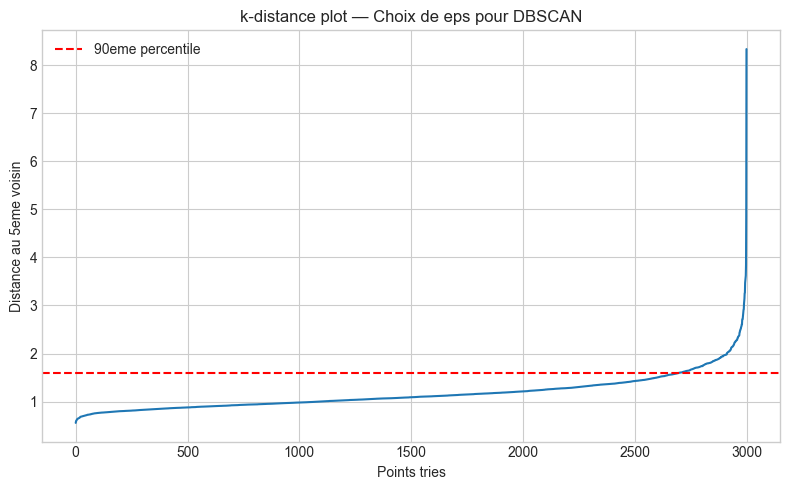

DBSCAN : 2 clusters trouves, 215 points de bruit (7.2%)
Taux de fraude dans le BRUIT (anomalies DBSCAN) : 0.47%
Taux de fraude dans les CLUSTERS : 0.04%
Ratio bruit/clusters : 13.0x
-> DBSCAN identifie les fraudes comme anomalies (bruit) !


In [33]:
# 1.1f DBSCAN — Clustering non supervise
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# k-distance pour choisir eps
sample_db = X_scaled[:3000]  # Sous-echantillon pour rapidite
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(sample_db)
distances, indices = neighbors_fit.kneighbors(sample_db)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_distances)
ax.set_xlabel('Points tries')
ax.set_ylabel('Distance au 5eme voisin')
ax.set_title('k-distance plot — Choix de eps pour DBSCAN')
ax.axhline(y=np.percentile(k_distances, 90), color='r', linestyle='--', label='90eme percentile')
ax.legend()
plt.tight_layout()
plt.show()

# DBSCAN
eps_value = np.percentile(k_distances, 90)
dbscan = DBSCAN(eps=eps_value, min_samples=10)
labels = dbscan.fit_predict(sample_db)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"DBSCAN : {n_clusters} clusters trouves, {n_noise} points de bruit ({n_noise/len(labels)*100:.1f}%)")

# Proportion de fraudes dans le bruit vs clusters
df_sample_labels = sample_labels.iloc[:3000]
noise_mask = labels == -1
fraud_in_noise = df_sample_labels[noise_mask].mean() if noise_mask.sum() > 0 else 0
fraud_in_clusters = df_sample_labels[~noise_mask].mean() if (~noise_mask).sum() > 0 else 0
print(f"Taux de fraude dans le BRUIT (anomalies DBSCAN) : {fraud_in_noise*100:.2f}%")
print(f"Taux de fraude dans les CLUSTERS : {fraud_in_clusters*100:.2f}%")
print(f"Ratio bruit/clusters : {fraud_in_noise/(fraud_in_clusters+1e-9):.1f}x")
print("-> DBSCAN identifie les fraudes comme anomalies (bruit) !")

## 1.7 Synthese EDA — Decisions pour le Preprocessing

### Constats principaux

1. **Desequilibre extreme** : 0.15% de fraudes. Accuracy naive = 99.85% mais F1 = 0 sur la classe fraude. Il faut :
   - Utiliser des metriques adaptees : **Precision-Recall AUC**, **F1-score**, **Matthews Correlation Coefficient (MCC)**
   - Appliquer des techniques de reequilibrage : **SMOTE**, **class_weight='balanced'**, ou **sous-echantillonnage**

2. **Patterns temporels** : Les fraudes ne sont pas uniformement distribuees dans le temps. Les heures de nuit et certains jours presentent des pics. L'heure (`hour`) et le flag `is_night` devraient etre des features importantes.

3. **Types de fraude distincts** : 5 types de fraude avec des comportements differents (montants, horaires). Une approche multi-classe ou un modele par type pourrait ameliorer la detection.

4. **Canaux a risque** : Certains canaux (API, web) et types de transactions (transfer) ont des taux de fraude plus eleves. Features a encoder (one-hot ou target encoding).

5. **KYC et pays** : Le niveau KYC est fortement correle au risque. Les comptes avec KYC faible (niveau 1) sont plus a risque. Le pays est aussi un indicateur.

6. **Graphe** : Les comptes fraudeurs ont des profils de degre et de flow_ratio differents des comptes normaux. Les features graphe (out_degree, in_degree, flow_ratio) enrichiront le modele.

### Decisions preprocessing

| Decision | Action |
|----------|--------|
| Split temporel | Train/Validation/Test par date (pas aleatoire) |
| Encodage | One-hot pour channel, transaction_type, country, kyc_level |
| Features cycliques | hour, day_of_week -> sin/cos |
| Features graphe | out_degree, in_degree, flow_ratio depuis nodes.csv |
| Scaling | StandardScaler pour features numeriques |
| Reequilibrage | SMOTE ou class_weight='balanced' |
| Metrique | Precision-Recall AUC + F1-score (pas accuracy) |
| Modeles cibles | XGBoost, LightGBM, Random Forest |